<a href="https://colab.research.google.com/github/sarvindhar-J/build-deploy/blob/main/EX5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

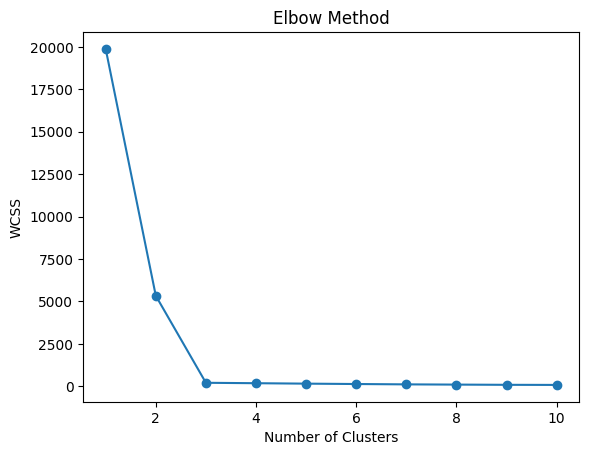

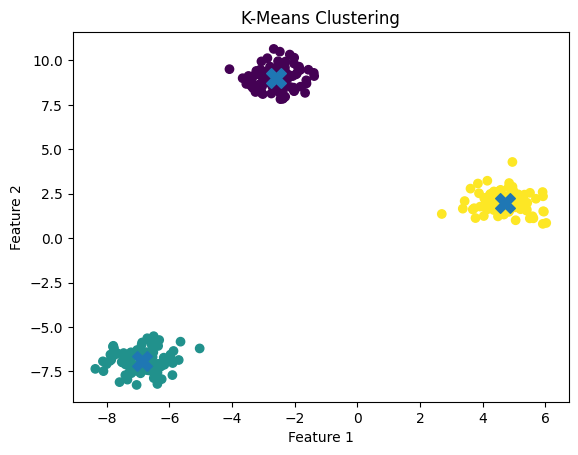

Silhouette Score: 0.9083834454815235
Explained Variance: [0.57208431 0.33622342]
Total Variance: 0.9083077323301143


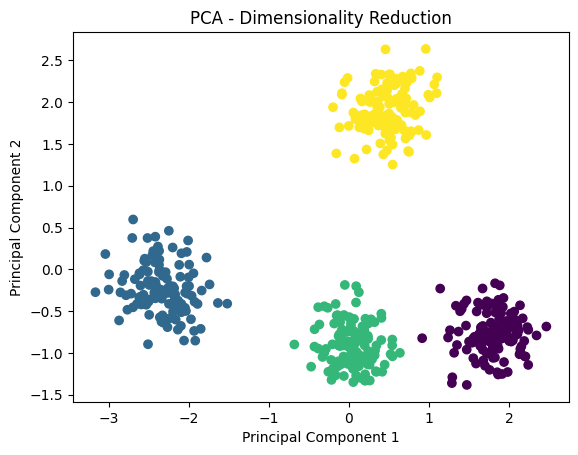

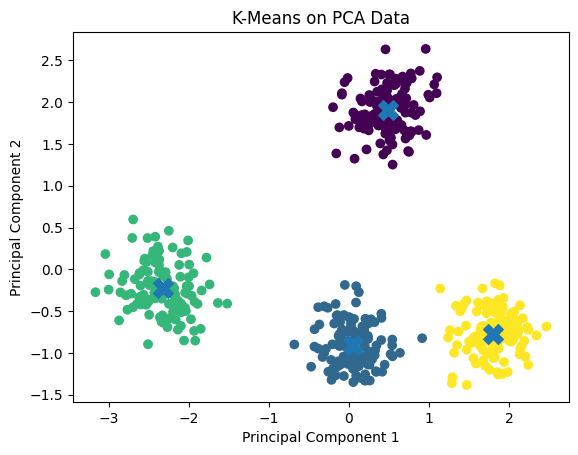

PCA K-Means Silhouette Score: 0.7764383951477865


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Part 1: K-Means Clustering
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

# Elbow Method
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, n_init=10, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Apply K-Means
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Silhouette Score:", silhouette_score(X, clusters))

# Part 2: PCA
X_pca, y_pca = make_blobs(
    n_samples=500, n_features=4, centers=4,
    cluster_std=1.0, random_state=25
)

# Standardize
X_scaled = StandardScaler().fit_transform(X_pca)

# PCA: 4D to 2D
pca = PCA(n_components=2)
principal = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance:", pca.explained_variance_ratio_.sum())

# PCA Visualization
plt.scatter(principal[:, 0], principal[:, 1], c=y_pca)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Dimensionality Reduction")
plt.show()

# K-Means on PCA data
kmeans_pca = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters_pca = kmeans_pca.fit_predict(principal)

plt.scatter(principal[:, 0], principal[:, 1], c=clusters_pca)
plt.scatter(kmeans_pca.cluster_centers_[:, 0],
            kmeans_pca.cluster_centers_[:, 1],
            s=200, marker='X')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means on PCA Data")
plt.show()

print("PCA K-Means Silhouette Score:",
      silhouette_score(principal, clusters_pca))